# Restaurant Marketing Prioritisation Pipeline

**Objective:** Generate a prioritised list of restaurants to market, based on both current performance and emerging growth trends.

**Inputs:**
- `restaurants_agg_performance.parquet` — from `momentum.ipynb`
- `activity_performance_with_roi.csv` — from `compare_bookings_with_marketing.ipynb`

**Output:** `priority_list.csv` — final ranked, actionable table

---

## Logic Overview

1. **Segment Stability Filter** — narrows the full restaurant universe to only those consistently in a growth segment over the last N months (~251 restaurants). All others are deprioritised.
2. **Within the 251**, restaurants are split by whether they have marketing history:
   - **With marketing history** → ranked by growth (60%) + marketing lift/ROI (40%)
   - **No marketing history** → ranked by growth only, flagged as Untapped
3. **Output** → one clean ranked list with tier label and recommended channel.

## 0) Configuration & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')

# ── Paths ─────────────────────────────────────────────────────────────────────
MOMENTUM_PATH  = Path('../_2_feature_engineering+momentum/start/restaurants_agg_performance.parquet')
MARKETING_PATH = Path('../_3_marketing/activity_performance_with_roi.csv')
OUTPUT_PATH    = Path('priority_list.csv')

# ── Stability filter ──────────────────────────────────────────────────────────
LOOKBACK_MONTHS   = 6   # look back N months for segment stability
MIN_GROWTH_MONTHS = 5   # must appear in a growth segment in at least this many months

GROWTH_SEGMENTS = ['Rising Stars', 'Emerging Opportunities']

# ── Score weights ─────────────────────────────────────────────────────────────
# Growth component (used for ALL restaurants)
W_SCORE_GROWTH = 0.60   # rolling growth trajectory
W_DELTA_GROWTH = 0.40   # acceleration (is growth speeding up?)

# Marketing component (used ONLY for restaurants with marketing history)
W_GROWTH_FINAL   = 0.60  # weight of growth component in final score
W_MARKETING_FINAL = 0.40  # weight of marketing component in final score
W_LIFT = 0.60            # avg lift per day within marketing component
W_ROI  = 0.40            # avg roi within marketing component

print('Configuration loaded.')

Configuration loaded.


## 1) Helper Functions

In [2]:
def min_max_norm(s: pd.Series) -> pd.Series:
    """Normalise a series to [0, 1]. Returns 0.5 uniformly if all values identical."""
    rng = s.max() - s.min()
    if rng == 0:
        return pd.Series(0.5, index=s.index)
    return (s - s.min()) / rng


def get_segment(row, perf_threshold, growth_threshold):
    """Assign 2x2 momentum segment based on performance and growth score thresholds."""
    is_big     = row['score_perf']   >= perf_threshold
    is_growing = row['score_growth'] >= growth_threshold
    if is_big and is_growing:
        return 'Rising Stars'
    if not is_big and is_growing:
        return 'Emerging Opportunities'
    if is_big and not is_growing:
        return 'Established Players'
    return 'Needs Attention'


def recommend_channel(row):
    """
    Recommend marketing channel:
      1. Use the restaurant's own best-performing channel if lift was positive.
      2. Fall back to segment-level heuristics if no history exists.
    """
    if (row['has_marketing']
            and pd.notna(row.get('best_channel'))
            and row.get('best_channel_avg_lift', 0) > 0):
        return row['best_channel']

    seg = row.get('latest_segment', '')
    if seg == 'Rising Stars':
        return 'KOL'   # amplify organic momentum with influencer reach
    if seg == 'Emerging Opportunities':
        return 'FB'    # paid reach to accelerate low-volume growth
    if seg == 'Established Players':
        return 'CRM'   # retention focus, not acquisition
    return 'CRM'


print('Helper functions defined.')

Helper functions defined.


## 2) Load Momentum Data

In [3]:
agg = pd.read_parquet(MOMENTUM_PATH)
agg['year_month'] = pd.to_datetime(agg['year_month'])

print(f'Momentum rows   : {len(agg):,}')
print(f'Restaurants     : {agg["name"].nunique():,}')
print(f'Date range      : {agg["year_month"].min().date()} → {agg["year_month"].max().date()}')
agg.head(3)

Momentum rows   : 11,640
Restaurants     : 1,693
Date range      : 2025-01-01 → 2026-01-01


,restaurant_id,name,year_month,monthly_bookings,monthly_revenue,avg_revenue_per_booking,avg_guests,active_days,in_analysis_window,booking_growth_mom,...,score_perf,score_growth,booking_growth_rolling_prev,revenue_growth_rolling_prev,log_bookings_prev,log_rev_prev,delta_growth_book,delta_growth_rev,delta_size_book,delta_size_rev
4,4800,Charoen Rung Rueang International Buffet MS S...,2025-01-01,20,10594.7,529.735000,2.650000,14,True,-0.047619,...,0.557899,0.266343,0.000000,0.000000,0.000000,0.000000,-0.130456,-0.168145,3.044522,9.268204
5,4800,Charoen Rung Rueang International Buffet MS S...,2025-02-01,32,18390.8,574.712500,2.875000,16,True,0.600000,...,0.629584,0.391388,-0.130456,-0.168145,3.044522,9.268204,0.314583,0.385956,0.451985,0.551457
6,4800,Charoen Rung Rueang International Buffet MS S...,2025-03-01,19,9995.0,526.052632,2.631579,11,True,-0.406250,...,0.550229,0.320951,0.184127,0.217810,3.496508,9.819660,-0.135417,-0.231539,-0.500775,-0.609720


## 3) Recompute Segments on Full History

In [4]:
# Compute thresholds from the latest month snapshot
latest_snap      = agg.sort_values('year_month').groupby('name').tail(1)
perf_threshold   = latest_snap['score_perf'].quantile(0.75)
growth_threshold = latest_snap['score_growth'].quantile(0.75)

print(f'Performance threshold (75th pct) : {perf_threshold:.4f}')
print(f'Growth threshold (75th pct)      : {growth_threshold:.4f}')

# Apply segment to every row in the full history
agg['segment'] = agg.apply(
    get_segment, axis=1,
    perf_threshold=perf_threshold,
    growth_threshold=growth_threshold
)

print('\nSegment distribution (all months):')
print(agg['segment'].value_counts())

Performance threshold (75th pct) : 0.2594
Growth threshold (75th pct)      : 0.4357

Segment distribution (all months):
segment
Needs Attention           4671
Established Players       3160
Rising Stars              2526
Emerging Opportunities    1283
Name: count, dtype: int64


## 4) Segment Stability Filter

A restaurant must appear in a **growth segment** (`Rising Stars` or `Emerging Opportunities`) in at least `MIN_GROWTH_MONTHS` of the last `LOOKBACK_MONTHS` months.

This filters out restaurants that had one lucky month and ensures we back **sustained momentum** rather than a spike.

**The ~251 restaurants that pass this filter form the working universe for all subsequent steps. All others are deprioritised.**

Restaurants with stable growth : 85
Latest segment distribution:
latest_segment
Needs Attention           920
Established Players       247
Emerging Opportunities    241
Rising Stars              170
Name: count, dtype: int64


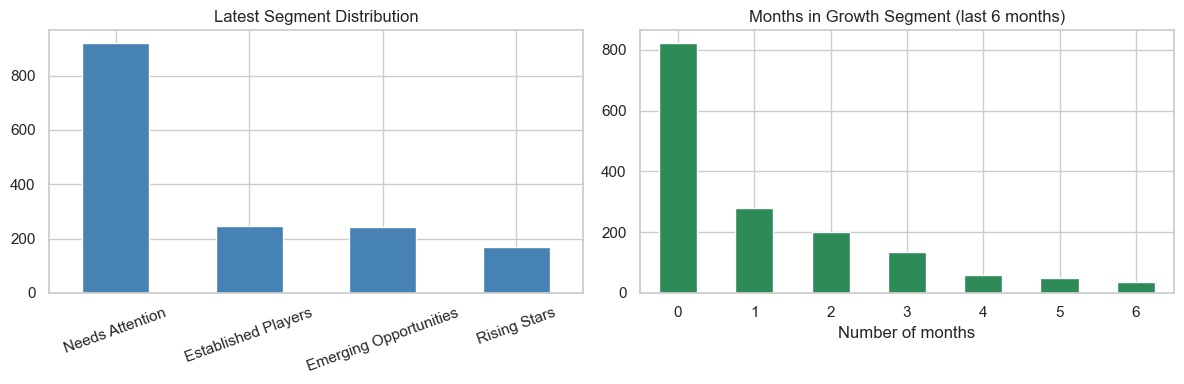

In [5]:
latest_month   = agg['year_month'].max()
lookback_start = latest_month - pd.DateOffset(months=LOOKBACK_MONTHS - 1)

trailing = agg[agg['year_month'] >= lookback_start].copy()
trailing['is_growth_segment'] = trailing['segment'].isin(GROWTH_SEGMENTS).astype(int)

stability = (
    trailing.groupby('name')
    .agg(
        growth_months   =('is_growth_segment', 'sum'),
        months_observed =('year_month',        'nunique'),
        latest_segment  =('segment',           'last'),
    )
    .reset_index()
)

stability['is_stable_growth'] = stability['growth_months'] >= MIN_GROWTH_MONTHS

print(f'Restaurants with stable growth : {stability["is_stable_growth"].sum():,}')
print(f'Latest segment distribution:')
print(stability['latest_segment'].value_counts())

# Visualise stability
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

stability['latest_segment'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Latest Segment Distribution')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

stability['growth_months'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title(f'Months in Growth Segment (last {LOOKBACK_MONTHS} months)')
axes[1].set_xlabel('Number of months')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 5) Build Latest Snapshot

In [6]:
latest = (
    agg.sort_values('year_month')
    .groupby('name')
    .tail(1)
    .copy()
)

latest = latest.merge(
    stability[['name', 'growth_months', 'months_observed', 'is_stable_growth', 'latest_segment']],
    on='name',
    how='left'
)

print(f'Latest snapshot: {len(latest):,} restaurants')
latest[['name', 'score_perf', 'score_growth', 'latest_segment', 'growth_months', 'is_stable_growth']].head(5)

Latest snapshot: 1,693 restaurants


,name,score_perf,score_growth,latest_segment,growth_months,is_stable_growth
0,MJ Hotpot,0.166380,0.373298,NaN,NaN,NaN
1,Patong Bay Hill Resort (Phuket),0.161588,0.433545,NaN,NaN,NaN
2,Pae Shabu & Grill House Ramkhamhaeng Housing,0.070262,0.320253,NaN,NaN,NaN
3,Shabushi Seacon Square,0.186780,0.509147,NaN,NaN,NaN
4,Melody Bangkok,0.126243,0.320253,NaN,NaN,NaN


## 6) Load & Aggregate Marketing Performance

Marketing lift is aggregated from activity level → restaurant level.
Restaurants without any campaigns will have `NaN` for all marketing columns — they are NOT excluded.

In [7]:
mkt = pd.read_csv(MARKETING_PATH)
mkt['restaurant_id'] = pd.to_numeric(mkt['restaurant_id'], errors='coerce')

print(f'Marketing activities : {len(mkt):,}')
print(f'Restaurants covered  : {mkt["restaurant_id"].nunique():,}')
print(f'Channels             : {mkt["channel"].unique()}')
mkt.head(3)

Marketing activities : 1,197
Restaurants covered  : 296
Channels             : ['CRM' 'FB' 'KOL']


,activity_id,bookings_during,bookings_baseline,lift,channel,restaurant_id,activity_start,activity_end,window_hours,crm_campaign_name,...,window_days,lift_per_day,cost_per_incremental_booking,total_campaign_revenue_x,aov_thb,total_campaign_revenue_y,total_campaign_revenue,incremental_revenue_thb,roi,roi_percentage
0,CRM_00e026f097bf,1.0,0.0,1.0,CRM,3122.0,2025-09-26,2025-09-28,48.0,TH_BKK_ctnoti_netcore_single_N_N_active_202509...,...,2.0,0.5,NaN,509.70,509.700,509.70,509.70,509.700,NaN,NaN
1,CRM_01166ffb3fba,1.0,2.0,-1.0,CRM,5828.0,2025-06-24,2025-06-26,48.0,TH_BKK_ctnoti_netcore_single_N_N_active_202506...,...,2.0,-0.5,NaN,609.96,609.960,609.96,609.96,-609.960,NaN,NaN
2,CRM_032b8a82c4d2,25.0,51.0,-26.0,CRM,370.0,2025-04-03,2025-04-05,48.0,TH_BKK_ctnoti_netcore_single_N_N_active_202504...,...,2.0,-13.0,NaN,5585.70,223.428,5585.70,5585.70,-5809.128,NaN,NaN


In [8]:
# Aggregate to restaurant level
rest_mkt = (
    mkt.groupby('restaurant_id')
    .agg(
        n_campaigns          =('activity_id',           'nunique'),
        avg_lift_per_day     =('lift_per_day',          'mean'),
        total_incremental_rev=('incremental_revenue_thb','sum'),
        avg_roi              =('roi',                   'mean'),
        n_positive_lift      =('lift', lambda x: (x > 0).sum()),
        n_negative_lift      =('lift', lambda x: (x < 0).sum()),
        channels_used        =('channel', lambda x: '+'.join(sorted(x.dropna().unique()))),
    )
    .reset_index()
)

# Best channel = channel with highest avg lift_per_day for this restaurant
best_ch = (
    mkt.groupby(['restaurant_id', 'channel'])['lift_per_day']
    .mean()
    .reset_index()
    .sort_values('lift_per_day', ascending=False)
    .drop_duplicates('restaurant_id')
    .rename(columns={'channel': 'best_channel', 'lift_per_day': 'best_channel_avg_lift'})
)

rest_mkt = rest_mkt.merge(
    best_ch[['restaurant_id', 'best_channel', 'best_channel_avg_lift']],
    on='restaurant_id', how='left'
)

print(f'Restaurants with marketing history: {len(rest_mkt):,}')
rest_mkt.head(3)

Restaurants with marketing history: 296


,restaurant_id,n_campaigns,avg_lift_per_day,total_incremental_rev,avg_roi,n_positive_lift,n_negative_lift,channels_used,best_channel,best_channel_avg_lift
0,33.0,2,0.233333,1506.671429,-11.326757,1,1,FB+KOL,KOL,1.800
1,220.0,2,-0.800000,-3128.858333,NaN,0,2,KOL,KOL,-0.800
2,222.0,7,0.357143,3468.398601,-1.119794,3,3,CRM+FB,CRM,1.875


## 7) Join Momentum + Marketing

Left join the 251 stable-growth restaurants with marketing performance data.
- Restaurants **with** marketing history get lift and ROI columns populated.
- Restaurants **without** marketing history get NaN for those columns — they are NOT excluded.

In [9]:
if 'restaurant_id' not in latest.columns:
    print('WARNING: restaurant_id not in momentum snapshot.')
    print('Fix: add restaurant_id to groupby in momentum.ipynb Cell 20, then re-run.')
    combined = latest.copy()
    combined['has_marketing'] = False
else:
    combined = latest.merge(rest_mkt, on='restaurant_id', how='left')
    combined['has_marketing'] = combined['n_campaigns'].notna()

# Ensure all marketing columns exist even if no rows matched the join
marketing_col_defaults = {
    'avg_lift_per_day'      : np.nan,
    'total_incremental_rev' : np.nan,
    'avg_roi'               : np.nan,
    'n_positive_lift'       : 0,
    'n_negative_lift'       : 0,
    'channels_used'         : np.nan,
    'best_channel'          : np.nan,
    'best_channel_avg_lift' : np.nan,
    'n_campaigns'           : np.nan,
}
for col, default in marketing_col_defaults.items():
    if col not in combined.columns:
        combined[col] = default

print(f'Total restaurants (post-join)     : {len(combined):,}')
print(f'With marketing history            : {combined["has_marketing"].sum():,}')
print(f'Without marketing history         : {(~combined["has_marketing"]).sum():,}')

Total restaurants (post-join)     : 1,693
With marketing history            : 296
Without marketing history         : 1,397


In [10]:
# Sanity check — confirm join result
print('Combined shape:', combined.shape)
print('Columns:', combined.columns.tolist())
print()

# Diagnose if restaurant_id overlap is low
if 'restaurant_id' in combined.columns:
    momentum_ids  = set(latest['restaurant_id'].dropna().astype(int))
    marketing_ids = set(mkt['restaurant_id'].dropna().astype(int))
    print(f'Momentum restaurant IDs  : {len(momentum_ids):,}')
    print(f'Marketing restaurant IDs : {len(marketing_ids):,}')
    print(f'Overlap                  : {len(momentum_ids & marketing_ids):,}')

Combined shape: (1693, 47)
Columns: ['restaurant_id', 'name', 'year_month', 'monthly_bookings', 'monthly_revenue', 'avg_revenue_per_booking', 'avg_guests', 'active_days', 'in_analysis_window', 'booking_growth_mom', 'revenue_growth_mom', 'booking_growth_yoy', 'revenue_growth_yoy', 'months_of_history', 'has_full_year', 'booking_growth_pct', 'revenue_growth_pct', 'growth_signal_used', 'booking_growth_rolling', 'revenue_growth_rolling', 'log_bookings', 'log_rev', 'score_perf', 'score_growth', 'booking_growth_rolling_prev', 'revenue_growth_rolling_prev', 'log_bookings_prev', 'log_rev_prev', 'delta_growth_book', 'delta_growth_rev', 'delta_size_book', 'delta_size_rev', 'segment', 'growth_months', 'months_observed', 'is_stable_growth', 'latest_segment', 'n_campaigns', 'avg_lift_per_day', 'total_incremental_rev', 'avg_roi', 'n_positive_lift', 'n_negative_lift', 'channels_used', 'best_channel', 'best_channel_avg_lift', 'has_marketing']

Momentum restaurant IDs  : 1,693
Marketing restaurant IDs :

## 8) Composite Priority Score

Only the **251 stable-growth restaurants** are scored and ranked.

```
With marketing history:
    priority_score = growth_component (60%) + marketing_component (40%)
    growth_component    = score_growth (60%) + delta_growth (40%)
    marketing_component = avg_lift_per_day (60%) + avg_roi (40%)

Without marketing history:
    priority_score = growth_component only (renormalised to 0–100)
```

Both groups are ranked together in the final list — the tier label clarifies the basis of the score.

In [11]:
# ── Filter to the stable-growth universe only ────────────────────────────────
priority_df = combined[combined['is_stable_growth'] == True].copy()
print(f'Working universe (stable growth): {len(priority_df):,} restaurants')
print(f'  With marketing history        : {priority_df["has_marketing"].sum():,}')
print(f'  Without marketing history     : {(~priority_df["has_marketing"]).sum():,}')

# ── Growth component (always present) ────────────────────────────────────────
delta_col = 'delta_growth_book' if 'delta_growth_book' in priority_df.columns else None

if delta_col:
    priority_df['delta_growth_norm'] = min_max_norm(priority_df[delta_col].fillna(0))
else:
    print('WARNING: delta_growth_book not found — acceleration signal set to 0.')
    priority_df['delta_growth_norm'] = 0.0

priority_df['score_growth_norm'] = min_max_norm(priority_df['score_growth'].fillna(0))

priority_df['growth_component'] = (
    priority_df['score_growth_norm'] * W_SCORE_GROWTH +
    priority_df['delta_growth_norm'] * W_DELTA_GROWTH
)

# ── Marketing component (only for restaurants with history) ───────────────────
priority_df['lift_norm'] = min_max_norm(
    priority_df['avg_lift_per_day'].fillna(0).clip(lower=0)
)
priority_df['roi_norm'] = min_max_norm(
    priority_df['avg_roi'].fillna(0).clip(lower=0)
)

priority_df['marketing_component'] = (
    priority_df['lift_norm'] * W_LIFT +
    priority_df['roi_norm']  * W_ROI
)

# ── Final composite score ─────────────────────────────────────────────────────
# With marketing: growth (60%) + marketing (40%)
# Without marketing: growth component only, renormalised
priority_df['priority_score'] = np.where(
    priority_df['has_marketing'],
    priority_df['growth_component'] * W_GROWTH_FINAL +
    priority_df['marketing_component'] * W_MARKETING_FINAL,
    min_max_norm(priority_df['growth_component'])
)

# Normalise final score to 0–100 for readability
priority_df['priority_score'] = min_max_norm(priority_df['priority_score']) * 100

print('\nScore distribution:')
print(priority_df['priority_score'].describe().round(2))

Working universe (stable growth): 85 restaurants
  With marketing history        : 58
  Without marketing history     : 27

Score distribution:
count     85.00
mean      37.24
std       18.55
min        0.00
25%       23.67
50%       34.18
75%       46.58
max      100.00
Name: priority_score, dtype: float64


## 9) Assign Priority Tier & Recommended Channel

Two simple tiers within the stable-growth restaurants:
- 🔴 **Activate — proven marketing response**: has marketing history and positive lift
- 🟠 **Activate — untapped, no prior spend**: no marketing history, growing organically

In [12]:
# ── Simple two-group tier label ──────────────────────────────────────────────
priority_df['priority_tier'] = np.where(
    priority_df['has_marketing'] & (priority_df['avg_lift_per_day'].fillna(0) > 0),
    '🔴 Activate — proven marketing response',
    np.where(
        ~priority_df['has_marketing'],
        '🟠 Activate — untapped, no prior spend',
        '🟡 Activate — review channel strategy'  # has marketing but lift was not positive
    )
)

priority_df['recommended_channel'] = priority_df.apply(recommend_channel, axis=1)

print('Priority tier distribution:')
print(priority_df['priority_tier'].value_counts())

Priority tier distribution:
priority_tier
🟡 Activate — review channel strategy      30
🔴 Activate — proven marketing response    28
🟠 Activate — untapped, no prior spend     27
Name: count, dtype: int64


## 10) Final Ranked Output

Ranked list of the ~251 stable-growth restaurants, sorted by priority score descending.

In [13]:
output_cols = [
    'name', 'restaurant_id',
    'priority_score', 'priority_tier', 'recommended_channel',
    'latest_segment', 'growth_months', 'months_observed', 'is_stable_growth',
    'score_perf', 'score_growth',
    'monthly_bookings', 'monthly_revenue',
    'booking_growth_rolling', 'revenue_growth_rolling',
    'delta_growth_book', 'delta_growth_rev',
    'has_marketing', 'n_campaigns',
    'avg_lift_per_day', 'total_incremental_rev',
    'avg_roi', 'n_positive_lift', 'n_negative_lift',
    'channels_used', 'best_channel',
]

output_cols = [c for c in output_cols if c in priority_df.columns]

priority_list = (
    priority_df[output_cols]
    .sort_values('priority_score', ascending=False)
    .reset_index(drop=True)
)
priority_list.index += 1
priority_list.index.name = 'rank'

priority_list.to_csv(OUTPUT_PATH)
print(f'Saved → {OUTPUT_PATH}')
print(f'Total restaurants ranked: {len(priority_list):,}')
priority_list.head(10)

Saved → priority_list.csv
Total restaurants ranked: 85


,name,restaurant_id,priority_score,priority_tier,recommended_channel,latest_segment,growth_months,months_observed,is_stable_growth,score_perf,...,delta_growth_rev,has_marketing,n_campaigns,avg_lift_per_day,total_incremental_rev,avg_roi,n_positive_lift,n_negative_lift,channels_used,best_channel
rank,,,,,,,,,,,,,,,,,,,,,
1,UNO MAS at Centara Grand Central World,2442,100.000000,"🟠 Activate — untapped, no prior spend",KOL,Rising Stars,5.0,5.0,True,0.431812,...,0.919145,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Baan Khanitha and Gallery Sathorn,1722,90.620169,"🟠 Activate — untapped, no prior spend",FB,Emerging Opportunities,6.0,6.0,True,0.204146,...,0.654015,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,One to taste Homemade Pasta,3708,82.487928,"🟠 Activate — untapped, no prior spend",FB,Emerging Opportunities,5.0,5.0,True,0.205789,...,0.515675,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Mr. Mala Hotpot Chaeng Watthana-Pak Kret 29,4843,76.840754,"🟠 Activate — untapped, no prior spend",KOL,Rising Stars,5.0,5.0,True,0.285640,...,-0.120706,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Kingston Lounge at Aira Hotel Bangkok,4831,67.184632,"🟠 Activate — untapped, no prior spend",KOL,Rising Stars,5.0,5.0,True,0.362306,...,0.235876,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Kunshine Hotpot Asok,4089,66.900086,🔴 Activate — proven marketing response,KOL,Rising Stars,6.0,6.0,True,0.380904,...,-0.840109,True,8.0,2.769048,17158.655693,2537.675521,6.0,2.0,CRM+FB+KOL,KOL
7,The Coffee Club Boat Lagoon (Phuket),3928,65.837492,"🟠 Activate — untapped, no prior spend",FB,Emerging Opportunities,5.0,5.0,True,0.184505,...,-0.229974,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Canale House,4884,63.105537,"🟠 Activate — untapped, no prior spend",KOL,Rising Stars,5.0,5.0,True,0.390786,...,-0.115668,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,57th Street Marriott Sukhumvit 57,1826,58.760246,🔴 Activate — proven marketing response,CRM,Rising Stars,5.0,5.0,True,0.892739,...,0.000000,True,10.0,1.060000,5591.163010,NaN,7.0,3.0,CRM+KOL,CRM


## 11) Visualisations

=== PRIORITY TIER SUMMARY ===
                                        count  avg_score  avg_growth  avg_lift_day
priority_tier                                                                     
🟠 Activate — untapped, no prior spend      27     47.693       0.578           NaN
🔴 Activate — proven marketing response     28     36.394       0.710         0.619
🟡 Activate — review channel strategy       30     28.616       0.658        -0.369


C:\Users\foogu\AppData\Local\Temp\ipykernel_31616\2051206984.py:27: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\foogu\AppData\Local\Temp\ipykernel_31616\2051206984.py:27: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\foogu\AppData\Local\Temp\ipykernel_31616\2051206984.py:27: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\foogu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\foogu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LA

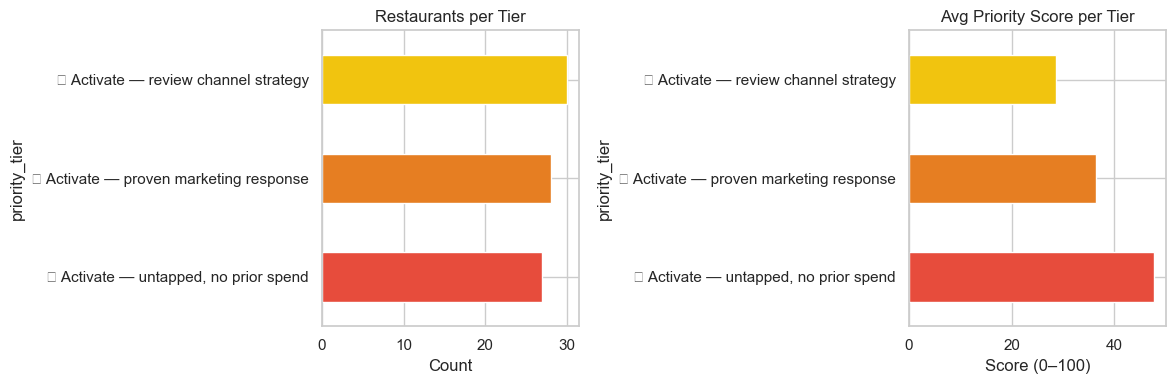

In [14]:
# ── Tier breakdown ────────────────────────────────────────────────────────────
tier_summary = (
    priority_list.groupby('priority_tier')
    .agg(
        count        =('priority_score',   'count'),
        avg_score    =('priority_score',   'mean'),
        avg_growth   =('score_growth',     'mean'),
        avg_lift_day =('avg_lift_per_day', 'mean'),
    )
    .round(3)
    .sort_values('avg_score', ascending=False)
)

print('=== PRIORITY TIER SUMMARY ===')
print(tier_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tier_summary['count'].plot(kind='barh', ax=axes[0], color=['#e74c3c', '#e67e22', '#f1c40f'])
axes[0].set_title('Restaurants per Tier')
axes[0].set_xlabel('Count')

tier_summary['avg_score'].plot(kind='barh', ax=axes[1], color=['#e74c3c', '#e67e22', '#f1c40f'])
axes[1].set_title('Avg Priority Score per Tier')
axes[1].set_xlabel('Score (0–100)')

plt.tight_layout()
plt.show()

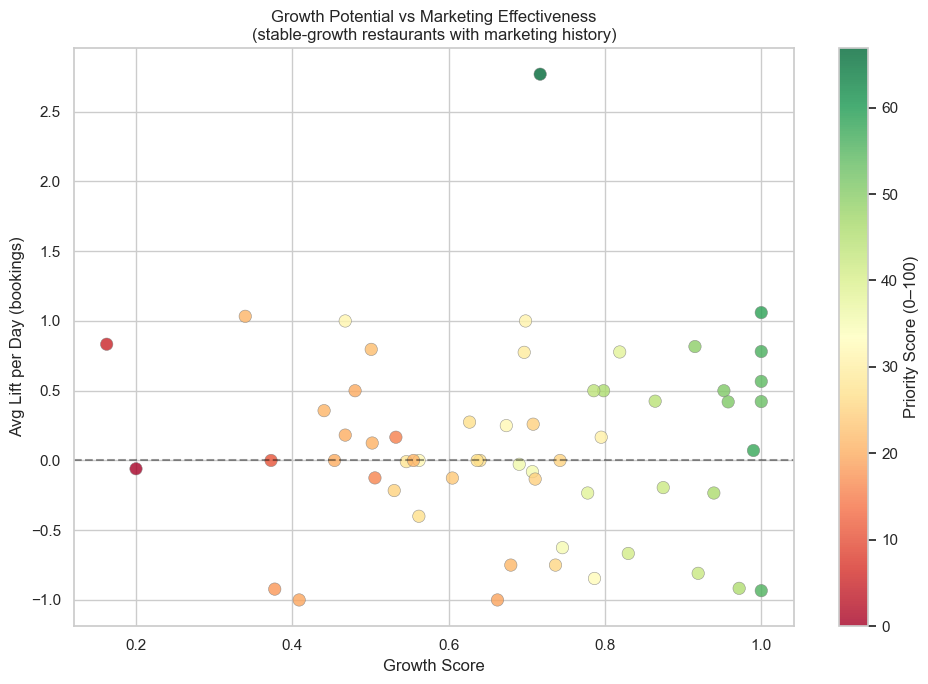

In [15]:
# ── Growth vs Marketing Lift scatter (stable-growth restaurants only) ─────────
plot_df = priority_list[priority_list['has_marketing']].copy()

if len(plot_df) == 0:
    print('No restaurants with marketing history in the priority list — skipping scatter.')
else:
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(
        plot_df['score_growth'],
        plot_df['avg_lift_per_day'].fillna(0),
        c=plot_df['priority_score'],
        cmap='RdYlGn',
        s=80,
        alpha=0.8,
        edgecolors='grey',
        linewidths=0.4
    )
    plt.colorbar(scatter, label='Priority Score (0–100)')
    plt.axhline(0, color='black', linestyle='--', alpha=0.4)
    plt.xlabel('Growth Score')
    plt.ylabel('Avg Lift per Day (bookings)')
    plt.title('Growth Potential vs Marketing Effectiveness\n(stable-growth restaurants with marketing history)')
    plt.tight_layout()
    plt.show()

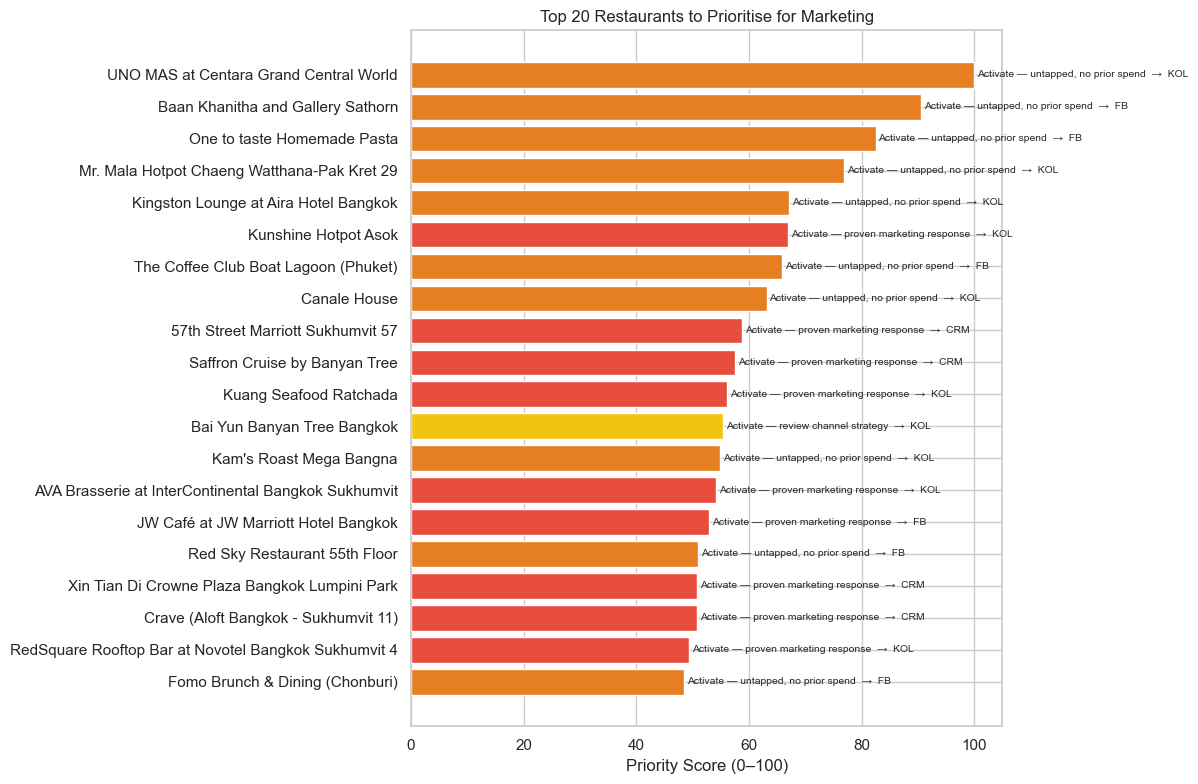

In [16]:
# ── Top 20 priority restaurants ──────────────────────────────────────────────
top20 = priority_list.head(20).copy()

tier_colors = {
    '🔴 Activate — proven marketing response' : '#e74c3c',
    '🟠 Activate — untapped, no prior spend'  : '#e67e22',
    '🟡 Activate — review channel strategy'   : '#f1c40f',
}
colors = top20['priority_tier'].map(tier_colors).fillna('#95a5a6')

plt.figure(figsize=(12, 8))
bars = plt.barh(top20['name'], top20['priority_score'], color=colors)
plt.xlabel('Priority Score (0–100)')
plt.title('Top 20 Restaurants to Prioritise for Marketing')
plt.gca().invert_yaxis()

for bar, (_, row) in zip(bars, top20.iterrows()):
    label = f"{row['priority_tier']}  →  {row.get('recommended_channel', '')}".replace('🔴 ', '').replace('🟠 ', '').replace('🟡 ', '')
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        label,
        va='center', fontsize=7.5
    )

plt.tight_layout()
plt.show()

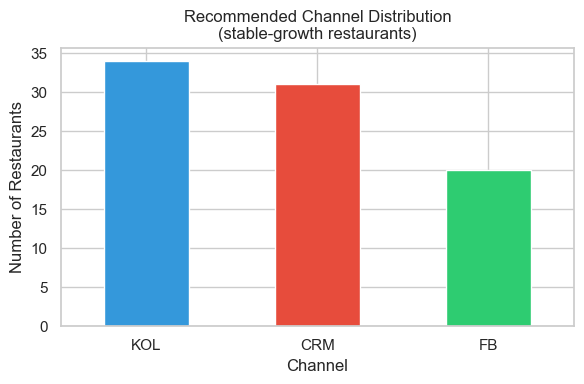

In [17]:
# ── Recommended channel distribution ─────────────────────────────────────────
ch_counts = priority_list['recommended_channel'].value_counts()

plt.figure(figsize=(6, 4))
ch_counts.plot(kind='bar', color=['#3498db', '#e74c3c', '#2ecc71'])
plt.title('Recommended Channel Distribution\n(stable-growth restaurants)')
plt.xlabel('Channel')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 12) Summary Table

Final actionable summary — one row per tier with key averages.

In [18]:
summary = (
    priority_list.groupby('priority_tier')
    .agg(
        n_restaurants        =('name',                'count'),
        avg_priority_score   =('priority_score',      'mean'),
        avg_growth_score     =('score_growth',        'mean'),
        avg_monthly_bookings =('monthly_bookings',    'mean'),
        avg_lift_per_day     =('avg_lift_per_day',    'mean'),
        avg_roi_pct          =('avg_roi',             'mean'),
        top_channel          =('recommended_channel', lambda x: x.value_counts().index[0]),
    )
    .round(2)
    .sort_values('avg_priority_score', ascending=False)
)

summary['avg_roi_pct'] = (summary['avg_roi_pct'] * 100).round(1).astype(str) + '%'

print('=== FINAL SUMMARY ===')
summary

=== FINAL SUMMARY ===


,n_restaurants,avg_priority_score,avg_growth_score,avg_monthly_bookings,avg_lift_per_day,avg_roi_pct,top_channel
priority_tier,,,,,,,
"🟠 Activate — untapped, no prior spend",27,47.69,0.58,3.63,NaN,nan%,FB
🔴 Activate — proven marketing response,28,36.39,0.71,31.46,0.62,42483.0%,CRM
🟡 Activate — review channel strategy,30,28.62,0.66,22.10,-0.37,1897.0%,KOL
